# Physics of climate change

follow the book [The Physics of Climate Change](https://www.amazon.com/Physics-Climate-Change-Lawrence-Krauss/dp/1642938165) by Lawrence M. Krauss.

In [98]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Keeling curve

In [82]:
mlo_data_file = 'https://raw.githubusercontent.com/sio-co2o2/keelingcurve_notebooks/main/preliminary_data/mlo/mlo_full_record_now_span.csv'
df_mlo = pd.read_csv(mlo_data_file, skipinitialspace=True, comment='"')

In [83]:
df_mlo = df_mlo[["date", "co2"]].copy()
df_mlo = df_mlo.dropna()

date_co2 = df_mlo["date"].to_numpy()
co2 = df_mlo["co2"].to_numpy()

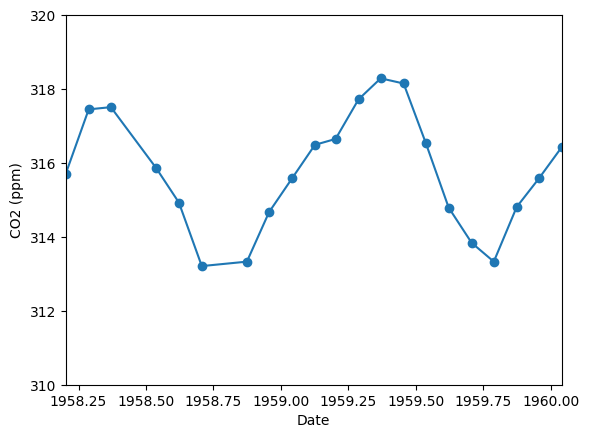

In [85]:
# plot from 1958 to 1960
plt.plot(date_co2, co2, marker="o", linestyle="-")
plt.xlabel("Date")
plt.ylabel("CO2 (ppm)")
plt.xlim(date_co2[0], date_co2[20])
plt.ylim(310, 320)
plt.show()

as if the earth is breathing.

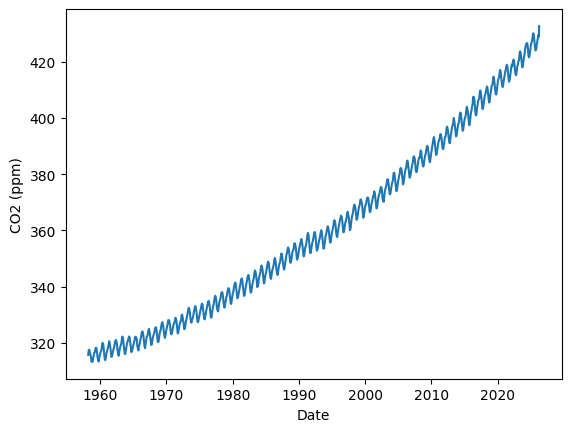

In [86]:
# plot full record
plt.plot(date_co2, co2)
plt.xlabel("Date")
plt.ylabel("CO2 (ppm)")
plt.show()

## Ice core data

In [87]:
# This is a subset of the full dataset found at https://doi.org/10.25919/5bfe29ff807fb
icecore_2K_data_file = 'https://raw.githubusercontent.com/sio-co2o2/keelingcurve_notebooks/main/icecore_data/Law_Dome_GHG_2000years_co2_by_age.csv'

# Get the icecore dataset back 800K years located at 
# the site: https://www.ncei.noaa.gov/access/paleo-search/study/6091
# the file: https://www.ncei.noaa.gov/pub/data/paleo/icecore/antarctica/epica_domec/edc-co2-2008.txt
# reference to the journal article at https://doi.org/10.1038/nature06949
icecore_800K_url = 'https://www.ncei.noaa.gov/pub/data/paleo/icecore/antarctica/epica_domec/edc-co2-2008.txt'

In [124]:
df_icecore_2K = pd.read_csv(icecore_2K_data_file, sep=',', comment='#', skipinitialspace=True)
df_icecore_2K = df_icecore_2K.sort_values(by=['CO2 Age (year AD)'], ascending=True).reset_index(drop=True)

df_icecore_2K = df_icecore_2K.drop(['Sample ID', 'Ice Age (year AD)', 'Uncert (ppm)'], axis=1).copy()
df_icecore_2K.columns = ['date_ce', 'co2']

# Keep only data before MLO starts (1958).
df_icecore_2K = df_icecore_2K[df_icecore_2K['date_ce'] < 1958].copy()

df_icecore_2K.head()

,date_ce,co2
0,154,278.2
1,175,277.7
2,241,280.4
3,266,278.4
4,274,280.2


Clean, align, and limit the 2K ice-core data to pre-MLO years (up to 1957).

Load and clean the 800K ice-core record, then convert years BP to CE and keep only points older than the 2K series.

The date column in this file is BP (before present), where present year = 1950.

In [125]:
import requests

response = requests.get(icecore_800K_url)
file_text = response.text
text_lines = file_text.split('\n')

# Find section 3: Composite CO2 record (0-800 kyr BP).
start_section = [
    i for i, line in enumerate(text_lines)
    if line.startswith('3. Composite CO2 record (0-800 kyr BP)')
][0]
section_lines = text_lines[start_section:]

# Data starts after the line: Age(yrBP)    CO2(ppmv)
header_end = [i for i, line in enumerate(section_lines) if line.startswith('Age(yrBP)')][0]
data_lines = section_lines[header_end + 1:]

# Parse text lines into a dataframe.
data_list = [line.rstrip() for line in data_lines]
df_icecore_800K = pd.DataFrame({'data': data_list})
df_icecore_800K[['date_bp', 'co2']] = df_icecore_800K['data'].str.split(pat=' ', n=1, expand=True)
df_icecore_800K = df_icecore_800K.drop(columns=['data'])

# Clean empty rows and convert to numeric.
df_icecore_800K['date_bp'] = df_icecore_800K['date_bp'].replace('', np.nan)
df_icecore_800K = df_icecore_800K.dropna().astype(float)

# Convert BP -> CE and keep only rows older than the 2K dataset start.
df_icecore_800K['date_ce'] = 1950 - df_icecore_800K['date_bp']
df_icecore_800K = df_icecore_800K.sort_values(by=['date_ce'], ascending=True).reset_index(drop=True)

min_2K = df_icecore_2K['date_ce'].min()
df_icecore_800K_subset = df_icecore_800K[df_icecore_800K['date_ce'] < min_2K].copy()
df_icecore_800K_subset = df_icecore_800K_subset.drop(columns=['date_bp'])
df_icecore_800K_subset = df_icecore_800K_subset.reindex(columns=['date_ce', 'co2'])

df_icecore_800K_subset.head()

,date_ce,co2
0,-796562.0,191.0
1,-795149.0,188.4
2,-794517.0,189.3
3,-793252.0,195.2
4,-792658.0,199.4


Combine the older 800K subset and the recent 2K ice-core dataset.

In [126]:
df_combined_icecore = pd.concat([df_icecore_800K_subset, df_icecore_2K], ignore_index=True)

Rename columns so will have same column names when combine with the icecore dataframe

In [127]:
df_mlo.columns = ['date_ce', 'co2']

df_mlo.head()

,date_ce,co2
2,1958.202740,315.71
3,1958.287671,317.45
4,1958.369863,317.51
6,1958.536986,315.87
7,1958.621918,314.93


Concatenate combined icecore with MLO data

and sort ascending

In [128]:
df_combined = pd.concat([df_combined_icecore, df_mlo], ignore_index=True)

# And reset the index
df_combined = df_combined.reset_index(drop=True)

# sort ascending
df_combined = df_combined.sort_values(by=['date_ce'], ascending=True)

df_combined[0:10]

,date_ce,co2
0,-796562.0,191.0
1,-795149.0,188.4
2,-794517.0,189.3
3,-793252.0,195.2
4,-792658.0,199.4
5,-791310.0,209.0
6,-790993.0,204.0
7,-790131.0,205.1
8,-789541.0,215.4
9,-788588.0,221.3


Convert back into units BP (before present)

In [129]:
# source, https://stackoverflow.com/questions/19305991/convert-fractional-years-to-a-real-date-in-python
from datetime import datetime, date, timedelta

def dt2t(adatetime):
    """
    Convert adatetime into a float. The integer part of the float should
    represent the year.
    Order should be preserved. If adate<bdate, then d2t(adate)<d2t(bdate)
    time distances should be preserved: If bdate-adate=ddate-cdate then
    dt2t(bdate)-dt2t(adate) = dt2t(ddate)-dt2t(cdate)
    """
    year = adatetime.year
    boy = datetime(year, 1, 1)
    eoy = datetime(year + 1, 1, 1)
    return year + ((adatetime - boy).total_seconds() / ((eoy - boy).total_seconds()))

In [130]:
def get_todays_date_variations():
    
    now = datetime.now()
    todays_decimal =  dt2t(now)
    
    today = date.today()

    todays_day = today.day
    todays_month = today.strftime("%B")
    todays_year = today.year
    todays_date_moyr = today.strftime("%B %Y")
    todays_date_modyyr = f"{todays_month} {todays_day}, {todays_year}"

    return todays_date_moyr, todays_date_modyyr, todays_decimal, todays_year

todays_date_moyr, todays_date_modyyr, todays_decimal, todays_year = get_todays_date_variations()

In [131]:
# years before now = present year - date ce
df_combined['date_bp'] = todays_decimal - df_combined['date_ce']
df_combined = df_combined.sort_values(by=['date_bp'], ascending=True)
combined_years_before_now = df_combined['date_bp'].to_numpy()

combined_co2 = df_combined['co2'].to_numpy()

## Multi-scale CO2 views

Three requested windows: 1700-current, 10,000 years ago-current, and 800,000 years ago-current.

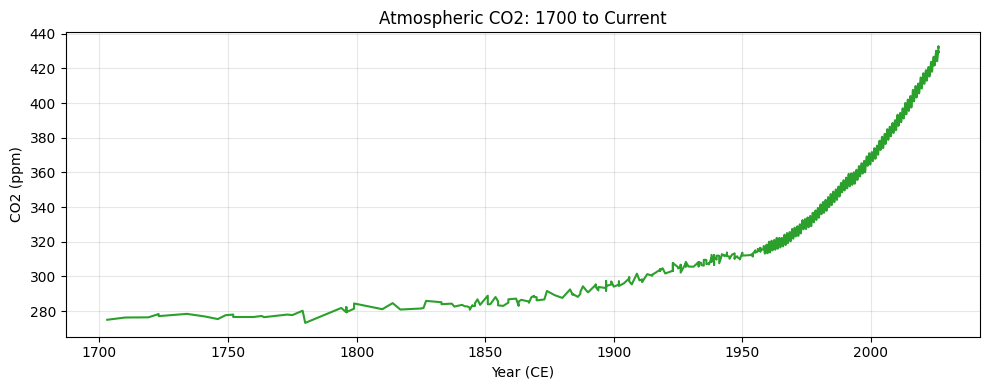

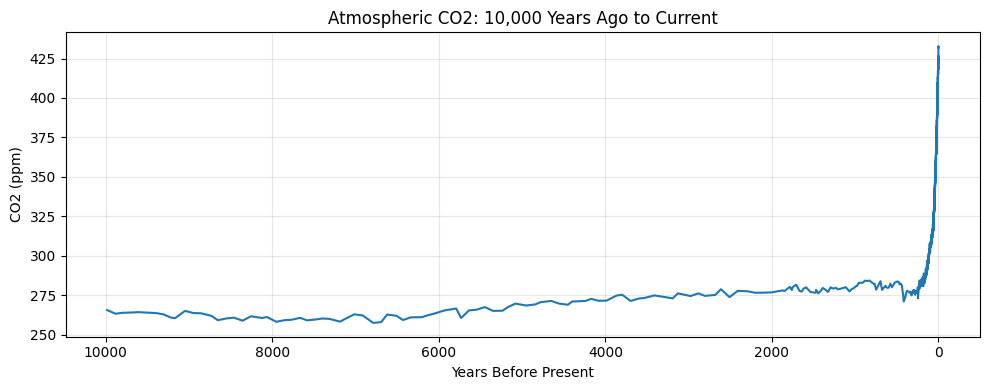

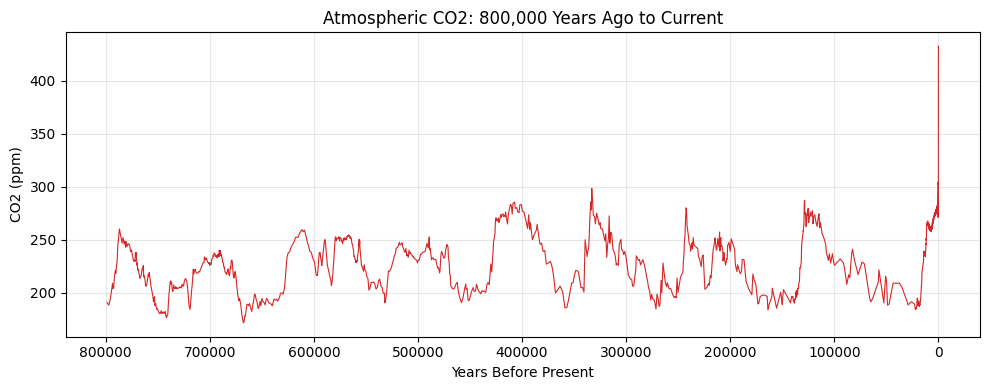

In [132]:
# 1) 1700 -> current (use CE years).
mask_1700 = df_combined['date_ce'] >= 1700
x_1700 = df_combined.loc[mask_1700, 'date_ce'].to_numpy()
y_1700 = df_combined.loc[mask_1700, 'co2'].to_numpy()

plt.figure(figsize=(10, 4))
plt.plot(x_1700, y_1700, color='tab:green')
plt.title('Atmospheric CO2: 1700 to Current')
plt.xlabel('Year (CE)')
plt.ylabel('CO2 (ppm)')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# 2) 10,000 years ago -> current (use years before present).
mask_10k = df_combined['date_bp'] <= 10_000
x_10k = df_combined.loc[mask_10k, 'date_bp'].to_numpy()
y_10k = df_combined.loc[mask_10k, 'co2'].to_numpy()

plt.figure(figsize=(10, 4))
plt.plot(x_10k, y_10k, color='tab:blue')
plt.title('Atmospheric CO2: 10,000 Years Ago to Current')
plt.xlabel('Years Before Present')
plt.ylabel('CO2 (ppm)')
plt.gca().invert_xaxis()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# 3) 800,000 years ago -> current (use years before present).
mask_800k = df_combined['date_bp'] <= 800_000
x_800k = df_combined.loc[mask_800k, 'date_bp'].to_numpy()
y_800k = df_combined.loc[mask_800k, 'co2'].to_numpy()

plt.figure(figsize=(10, 4))
plt.plot(x_800k, y_800k, color='tab:red', linewidth=0.8)
plt.title('Atmospheric CO2: 800,000 Years Ago to Current')
plt.xlabel('Years Before Present')
plt.ylabel('CO2 (ppm)')
plt.gca().invert_xaxis()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Human contribution

CO2 emission

In [135]:
co2_emission_file = 'https://raw.githubusercontent.com/owid/co2-data/master/owid-co2-data.csv'
df_co2_emission = pd.read_csv(co2_emission_file)

In [140]:
df_co2_emission.head()

,country,year,iso_code,population,gdp,cement_co2,cement_co2_per_capita,co2,co2_growth_abs,co2_growth_prct,...,share_global_other_co2,share_of_temperature_change_from_ghg,temperature_change_from_ch4,temperature_change_from_co2,temperature_change_from_ghg,temperature_change_from_n2o,total_ghg,total_ghg_excluding_lucf,trade_co2,trade_co2_share
0,Afghanistan,1750,AFG,2802560.0,NaN,0.0,0.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Afghanistan,1751,AFG,NaN,NaN,0.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Afghanistan,1752,AFG,NaN,NaN,0.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Afghanistan,1753,AFG,NaN,NaN,0.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Afghanistan,1754,AFG,NaN,NaN,0.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


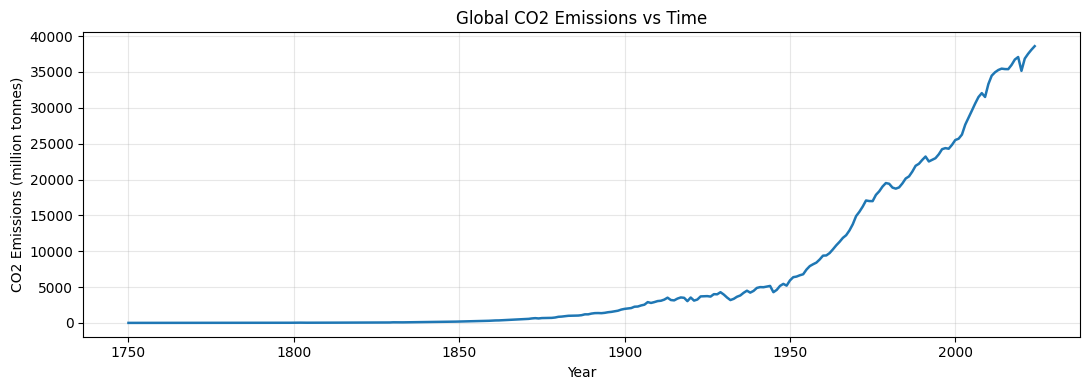

,year,co2
49781,2020,35158.230
49782,2021,36866.863
49783,2022,37527.773
49784,2023,38094.039
49785,2024,38598.578


In [142]:
# Plot overall (global) CO2 emissions vs time.
if 'country' in df_co2_emission.columns:
    df_world_co2 = df_co2_emission[df_co2_emission['country'] == 'World'][['year', 'co2']].dropna().copy()
else:
    # Fallback for schemas using world iso_code only.
    df_world_co2 = df_co2_emission[df_co2_emission['iso_code'] == 'OWID_WRL'][['year', 'co2']].dropna().copy()

plt.figure(figsize=(11, 4))
plt.plot(df_world_co2['year'], df_world_co2['co2'], color='tab:blue', linewidth=1.8)
plt.title('Global CO2 Emissions vs Time')
plt.xlabel('Year')
plt.ylabel('CO2 Emissions (million tonnes)')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

df_world_co2.tail()

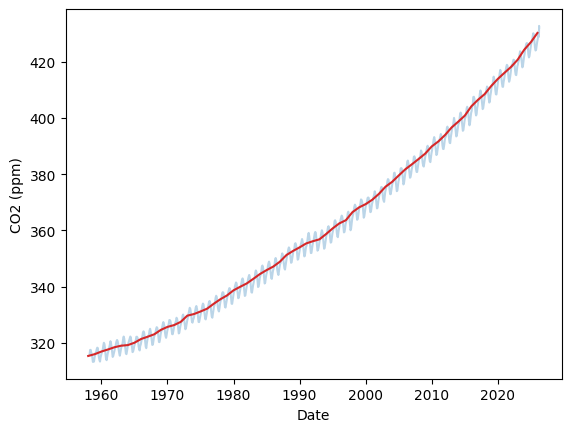

In [146]:
# plot yearly mean of keeling curve
keeling_mean = df_mlo.groupby(df_mlo['date_ce'].astype(int))['co2'].mean().reset_index()
keeling_mean.columns = ['date_ce', 'co2']

plt.plot(date_co2, co2, color='tab:blue', alpha=0.3, label='Monthly Mean')
plt.plot(keeling_mean['date_ce'], keeling_mean['co2'], color='tab:red', label='Yearly Mean')
plt.xlabel("Date")
plt.ylabel("CO2 (ppm)")
plt.show()

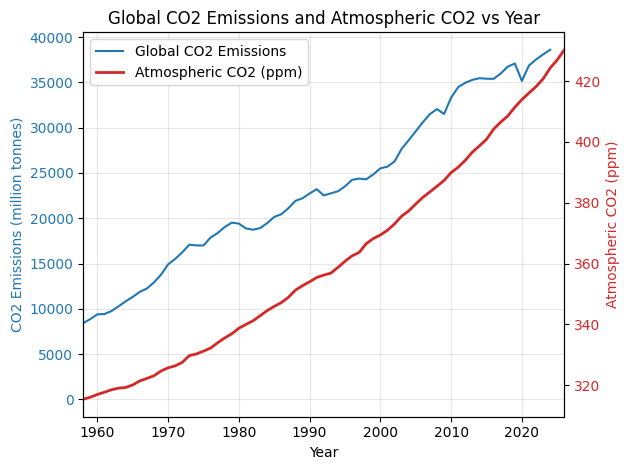

In [154]:
# Plot global CO2 emissions (left y-axis) and atmospheric CO2 ppm (right y-axis) vs year.
if 'country' in df_co2_emission.columns:
    df_world_co2 = df_co2_emission[df_co2_emission['country'] == 'World'][['year', 'co2']].dropna().copy()
else:
    df_world_co2 = df_co2_emission[df_co2_emission['iso_code'] == 'OWID_WRL'][['year', 'co2']].dropna().copy()

# Keeling data converted to yearly mean to align with emissions timescale.
keeling_yearly = df_mlo.groupby(df_mlo['date_ce'].astype(int))['co2'].mean().reset_index()
keeling_yearly.columns = ['year', 'co2_ppm']

fig, ax1 = plt.subplots()

# Left axis: CO2 emissions
line1, = ax1.plot(df_world_co2['year'], df_world_co2['co2'], color='tab:blue', label='Global CO2 Emissions')
ax1.set_xlabel('Year')
ax1.set_ylabel('CO2 Emissions (million tonnes)', color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')
ax1.grid(alpha=0.3)

# Right axis: atmospheric CO2 ppm (Keeling yearly mean)
ax2 = ax1.twinx()
line2, = ax2.plot(keeling_yearly['year'], keeling_yearly['co2_ppm'], color='tab:red', linewidth=2, label='Atmospheric CO2 (ppm)')
ax2.set_ylabel('Atmospheric CO2 (ppm)', color='tab:red')
ax2.tick_params(axis='y', labelcolor='tab:red')

ax1.set_title('Global CO2 Emissions and Atmospheric CO2 vs Year')
ax1.legend([line1, line2], [line1.get_label(), line2.get_label()], loc='upper left')

plt.xlim(1958, 2026)
plt.tight_layout()
plt.show()